# DecodeLabs Internship Week-1

In [7]:
import pandas as pd
df = pd.read_excel("../data/raw_data.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [8]:
df.shape

(1200, 14)

The dataset have 1200 rows and 14 columns.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [12]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [13]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

The CouponCode column in the dataset have missing values.

In [14]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [15]:
df_cleaned = df.copy()

In [17]:
df_cleaned.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [18]:
df_cleaned.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [19]:
df_cleaned['CouponCode'] = df_cleaned['CouponCode'].fillna('No Coupon')

In [20]:
df_cleaned['CouponCode'].isnull().sum()

np.int64(0)

#### Handling Missing Values
The CouponCode column contained 309 null values.
Since missing coupons likely indicate no promotional usage,
null values were replaced with "No Coupon".

In [22]:
# Checking duplicates
df_cleaned.duplicated().sum()

np.int64(0)

There are no duplicate values present in dataset which also means OrderId column have unique values.

In [23]:
df_cleaned.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [26]:
# check data types
df_cleaned.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [27]:
df_cleaned['OrderID'].duplicated().sum()

np.int64(0)

In [28]:
df_cleaned['TotalCalculated'] = (df_cleaned['Quantity'] * df_cleaned['UnitPrice'])

In [30]:
df_cleaned[['TotalPrice','TotalCalculated']].head()

,TotalPrice,TotalCalculated
0,2853.10,2853.10
1,302.70,302.70
2,2753.40,2753.40
3,273.19,273.19
4,2504.04,2504.04


In [32]:
(df_cleaned['TotalPrice'] != df_cleaned['TotalCalculated']).sum()

np.int64(107)

In [37]:
incorrect_prices = df_cleaned[
    df_cleaned['TotalPrice']
    != df_cleaned['TotalCalculated']
]

incorrect_prices.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TotalCalculated
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
10,ORD200010,2023-12-29,C43443,Tablet,5,625.97,333 Main St,Credit Card,Returned,TRK98859248,9,WINTER15,Instagram,3129.85,3129.85
11,ORD200011,2024-02-17,C93861,Monitor,3,49.14,831 Main St,Online,Returned,TRK48234646,7,SAVE10,Email,147.42,147.42
32,ORD200032,2023-05-01,C12388,Tablet,5,536.72,830 Main St,Cash,Delivered,TRK99261395,10,No Coupon,Email,2683.60,2683.60
41,ORD200041,2023-12-05,C20212,Monitor,3,611.45,657 Main St,Gift Card,Pending,TRK69733327,4,FREESHIP,Instagram,1834.35,1834.35


In [38]:
df_cleaned['TotalCalculated'] = (
    df_cleaned['Quantity']
    * df_cleaned['UnitPrice']
).round(2)

In [39]:
(
    df_cleaned['TotalPrice']
    != df_cleaned['TotalCalculated']
).sum()

np.int64(29)

In [40]:
price_mismatch = df_cleaned[
    df_cleaned['TotalPrice']
    != df_cleaned['TotalCalculated']
]

price_mismatch.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TotalCalculated
39,ORD200039,2025-02-27,C96664,Printer,3,256.46,666 Main St,Credit Card,Delivered,TRK85508960,4,SAVE10,Referral,769.38,769.38
66,ORD200066,2024-11-15,C18104,Chair,5,127.18,715 Main St,Cash,Cancelled,TRK15488568,9,SAVE10,Referral,635.90,635.90
85,ORD200085,2024-09-09,C14553,Tablet,3,146.73,768 Main St,Cash,Delivered,TRK93538334,8,FREESHIP,Email,440.19,440.19
111,ORD200111,2025-05-07,C95271,Desk,3,309.22,620 Main St,Online,Cancelled,TRK74904969,7,FREESHIP,Google,927.66,927.66
113,ORD200113,2024-01-17,C65905,Laptop,5,190.08,605 Main St,Cash,Shipped,TRK73954365,9,FREESHIP,Instagram,950.40,950.40
123,ORD200123,2023-07-06,C86064,Desk,3,278.04,727 Main St,Online,Delivered,TRK62182901,5,No Coupon,Instagram,834.12,834.12
190,ORD200190,2024-08-31,C35483,Printer,3,223.70,725 Main St,Cash,Returned,TRK79638203,3,SAVE10,Email,671.10,671.10
202,ORD200202,2025-02-06,C36938,Monitor,3,253.98,636 Main St,Credit Card,Cancelled,TRK52522904,3,FREESHIP,Email,761.94,761.94
225,ORD200225,2024-03-13,C99879,Phone,3,273.96,692 Main St,Debit Card,Returned,TRK50246700,8,SAVE10,Google,821.88,821.88
254,ORD200254,2023-12-26,C10866,Monitor,3,263.19,770 Main St,Online,Delivered,TRK34809583,5,No Coupon,Instagram,789.57,789.57


In [41]:
# the value showcase is same so we will use rounded values
(
    df_cleaned['TotalPrice'].round(2)
    !=
    df_cleaned['TotalCalculated'].round(2)
).sum()

np.int64(0)

In [44]:
import numpy as np

df_cleaned['PriceValidation'] = np.isclose(
    df_cleaned['TotalPrice'],
    df_cleaned['TotalCalculated'],
    atol=0.01
)
# new approach to check values within allowed tolerance

### Floating Point Precision Validation

During transactional validation, apparent mismatches
were observed between TotalPrice and recalculated totals.

Further inspection revealed that these discrepancies
were caused by floating-point precision limitations
rather than true business inconsistencies.

Tolerance-based comparison using NumPy's `isclose()`
was applied to validate financial accuracy reliably.

In [45]:
df_cleaned['PriceValidation'].value_counts()

PriceValidation
True    1200
Name: count, dtype: int64

In [46]:
# standardize columns to remove extra spaces and checking consistency
text_cols = [
    'Product',
    'ShippingAddress',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode',
    'ReferralSource'
]

for col in text_cols:
    df_cleaned[col] = df_cleaned[col].str.strip()

In [52]:
for col in text_cols:
    df_cleaned[col] = df_cleaned[col].str.title()
    

In [53]:

for col in text_cols:
    print(df_cleaned[col].value_counts())
    print("\n")

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


ShippingAddress
533 Main St    8
895 Main St    6
146 Main St    5
562 Main St    5
636 Main St    5
              ..
520 Main St    1
459 Main St    1
539 Main St    1
556 Main St    1
201 Main St    1
Name: count, Length: 655, dtype: int64


PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


CouponCode
Freeship     313
No Coupon    309
Winter15     292
Save10       286
Name: count, dtype: int64


ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64




In [54]:
df_cleaned.to_csv("final.csv",index=False)


All columns were verified and corrected to appropriate
data types. All numerical and categorical columns were validated
for analytical consistency.

### Final dataset with mini EDA

In [56]:
df = pd.read_csv("final.csv")

In [57]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TotalCalculated,PriceValidation
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,Save10,Instagram,2853.10,2853.10,True
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,Save10,Referral,302.70,302.70,True
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,Freeship,Email,2753.40,2753.40,True
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,Save10,Facebook,273.19,273.19,True
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,Save10,Email,2504.04,2504.04,True


In [58]:
# Most sold products
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [76]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

<Axes: xlabel='Product', ylabel='count'>

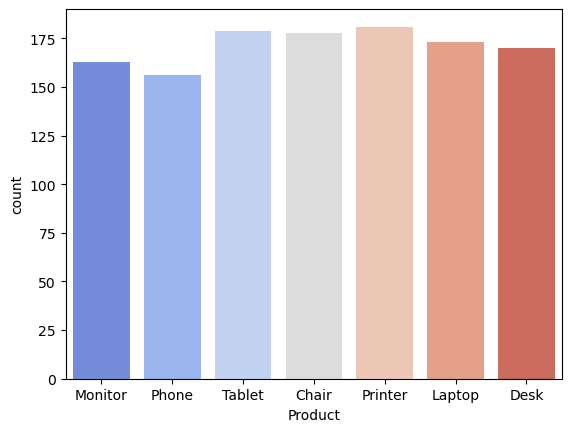

In [77]:
sns.countplot(data=df, x='Product', palette='coolwarm')

In [61]:
# Revenue by product
df.groupby('Product')['TotalPrice'].sum()

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64

<Axes: xlabel='Product', ylabel='TotalPrice'>

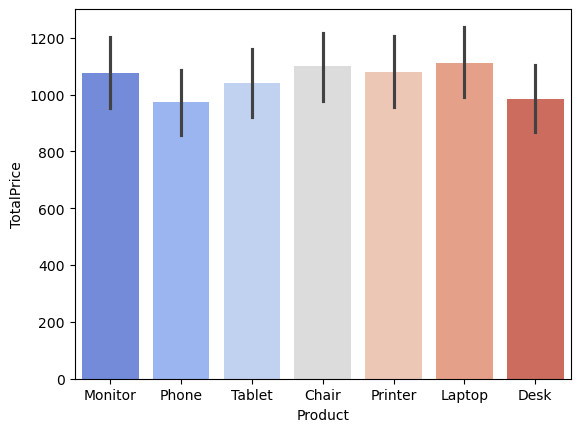

In [78]:
sns.barplot(data=df, x='Product', y='TotalPrice', palette='coolwarm')

In [67]:
# most used payment method
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='PaymentMethod'>

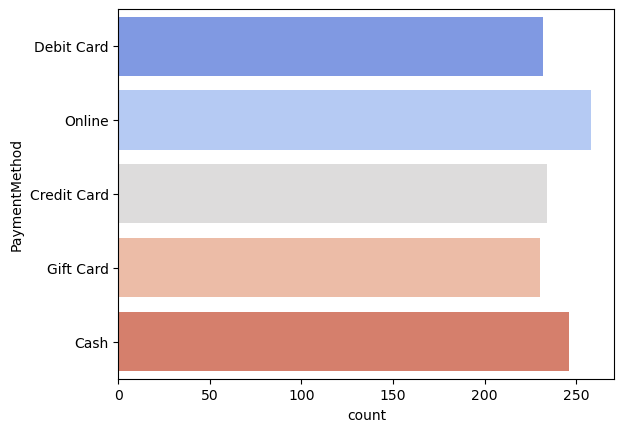

In [79]:
sns.countplot(df['PaymentMethod'], palette='coolwarm')

In [70]:
# Coupon usage
df['CouponCode'].value_counts()

CouponCode
Freeship     313
No Coupon    309
Winter15     292
Save10       286
Name: count, dtype: int64

<Axes: xlabel='CouponCode', ylabel='count'>

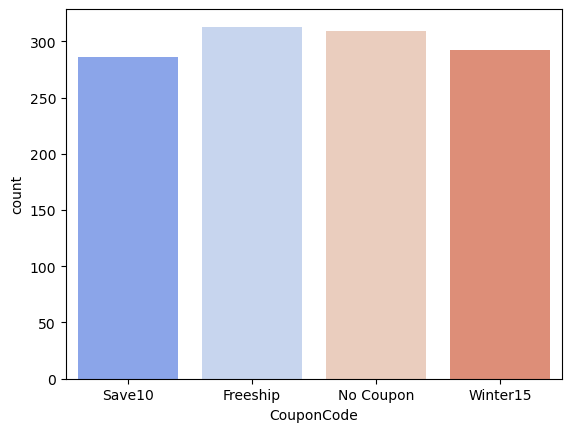

In [80]:
sns.countplot(x=df['CouponCode'], palette='coolwarm')

In [72]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='OrderStatus'>

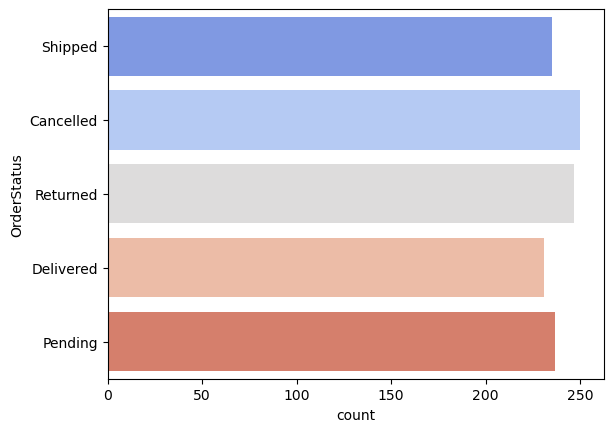

In [81]:
sns.countplot(df['OrderStatus'],  palette='coolwarm')

#### Gained insights
- Printer is the highest sold product
- Though chair is sold at a low quanity than printer still its revenue is much higher than printer
- Most of the users prefer Online as payement method but there is not much difference between all methods
- CouponCode distribution is mostly equal
- The orders are cancelled and returned at a higher rate than a successful delivery rate